<a href="https://colab.research.google.com/github/seanwu-bit/Automated-Regional-Impact-Auditor-ARIA-/blob/aria_4.0/ARIA_V4.0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 7 Assignment: ARIA v4.0 (The Accessible Auditor)

**Student Worksheet** — Fill in the code cells using AI assistance or your own code.

**Submission Deadline**: Before next class

**Learning Objectives**:
- Master OSMnx road network extraction and projection
- Implement betweenness centrality analysis
- Construct rainfall → congestion dynamic weighting system
- Calculate pre/post-disaster isochrones and accessibility changes
- (Advanced) Use AI to generate disaster response recommendations

---

註：作業改用Yilan市為Study Area


##更新並寫入.env檔案
透過%%writefile寫入
(作業繳交時將此Cell刪除)

## Part 0: Environment Setup

Confirm the following packages are installed:`osmnx`, `networkx`, `geopandas`, `pandas`, `numpy`, `matplotlib`, `shapely`

註：補充掛載Google Drive、讀取Week6檔案之步驟

In [ ]:
# 安裝路網分析與網格處理所需套件
!pip install osmnx networkx rasterio python-dotenv --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 4.0 MB/s eta 0:00:00


In [86]:
# [S1] Environment Setup
import os
import osmnx as ox
from dotenv import load_dotenv
import networkx as nx
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams
import warnings
import rasterio # Added this import
warnings.filterwarnings('ignore')

# Check version
print(f"OSMnx: {ox.__version__}")
print(f"NetworkX: {nx.__version__}")
print(f"GeoPandas: {gpd.__version__}")

# Font configuration (If Chinese language support is needed)
rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'DejaVu Sans']  # fallback
rcParams['axes.unicode_minus'] = False

from google.colab import drive
import os

# 掛載 Google Drive
drive.mount('/content/drive')

# 掛載Week6資料
output_dir = '/content/drive/MyDrive/ARIA_outputs'

rainfall_path = os.path.join(output_dir, 'Event2_1030_kriging_rainfall.tif')
variance_path = os.path.join(output_dir, 'Event2_1030_kriging_variance.tif')

print(f"Rainfall TIFF exists: {os.path.exists(rainfall_path)}")
print(f"Variance TIFF exists: {os.path.exists(variance_path)}")

OSMnx: 2.1.0
NetworkX: 3.6.1
GeoPandas: 1.1.3
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Rainfall TIFF exists: True
Variance TIFF exists: True


## Part A: Road Network Extraction & Travel Time Calculation

### Task A.1: Road Network Extraction

Use OSMnx to extract from OpenStreetMap**花蓮** (or choose your own township) road network.

**Tips**:
- Use `ox.graph_from_place()` or `ox.graph_from_address()`
- Set `network_type='drive'` Extract only car roads
- OSMnx ≥2.0 Road network already auto-simplified,no additional calls needed `simplify_graph()`
- use `ox.project_graph(G, to_crs='EPSG:3826')` Project to meter coordinates

註：更改使用Yilan City

In [96]:
# [S2] Attempt Road Network Extraction
# If using place name, confirm the location exists (e.g., "Hualien City, Taiwan")
load_dotenv()
place_name = os.getenv('PLACE_NAME', 'Suao Country, Taiwan')
dist_meters = int(os.getenv('SEARCH_RADIUS', 5000))
network_type = 'drive'
dist_meters = 5000  # Search radius (meters)

print(f"📍 Extracting {place_name} road network...")

try:
    # TODO: Use ox.graph_from_address() to extract road network
    G = ox.graph_from_address(place_name, dist=dist_meters, network_type=network_type)
    print(f"✅ Extraction successful: {G.number_of_nodes()} Node(s), {G.number_of_edges()} edge(s)")
except Exception as e:
    print(f"❌ Extraction failed: {e}")
    print("Possible causes:")
    print("  - Location name does not existor format error")
    print("  - Network connection issue (Overpass API Timeout)")
    print("  - Recommend waiting a few minutes and retry,oruse ox.settings.timeout = 300")


📍 Extracting Yilan, Taiwan road network...
✅ Extraction successful: 1698 Node(s), 4571 edge(s)


In [ ]:
# [S3] Project to Meter Coordinates
# Note: OSMnx >=2.0 automatically simplifies, no manual call needed simplify_graph()

# TODO: Project to EPSG:3826 (TWD97/TM2)
G_proj = ox.project_graph(G, to_crs='EPSG:3826')

print(f"Node count: {G_proj.number_of_nodes()}")
print(f"Number of edges: {G_proj.number_of_edges()}")
print(f"CRS: {G_proj.graph['crs']}")
print("✅ Projection complete")


Node count: 1698
Number of edges: 4571
CRS: EPSG:3826
✅ Projection complete


In [90]:
# [S4] Calculate Travel Time
# Calculate base travel time for each edge (unit: seconds)

# 1. 設定輸出目錄與檔案路徑
output_dir = '/content/drive/MyDrive/ARIA_outputs'
# 確保資料夾存在，若不存在則自動建立
os.makedirs(output_dir, exist_ok=True)
graphml_filename = os.path.join(output_dir, 'yilan_network.graphml')
# Highway type speed reference table (consistent with Demo Cell [3])
speed_defaults = {
    'motorway': 110, 'motorway_link': 80,
    'trunk': 100, 'trunk_link': 60,
    'primary': 80, 'primary_link': 50,
    'secondary': 60, 'secondary_link': 40,
    'tertiary': 50, 'tertiary_link': 30,
    'residential': 40, 'living_street': 10,
    'unclassified': 30,
}

def get_speed(data):
    """From OSM edge data Get speed (km/h),and Demo Cell [3] Consistent."""
    maxspeed = data.get('maxspeed', None)
    if maxspeed:
        try:
            return float(maxspeed)
        except (ValueError, TypeError):
            if isinstance(maxspeed, list):
                try:
                    return float(maxspeed[0])
                except:
                    pass
    highway = data.get('highway', 'residential')
    if isinstance(highway, list):
        highway = highway[0]
    return speed_defaults.get(highway, 40)

# TODO: Traverse all edges,Calculate travel_time_normal
travel_times = []
edge_info_list = []

print("⏱️ 正在計算所有 edge 的 length, speed_kph 與 travel_time...")

# 2. 走訪所有路段並計算屬性
for u, v, k, data in G_proj.edges(keys=True, data=True):
    # 取得長度 (預設為 1.0，避免極端異常圖資造成錯誤)
    length = data.get('length', 1.0)

    # 取得速限並轉換為 m/s
    speed_kph = get_speed(data)
    speed_mps = speed_kph / 3.6

    # 計算 travel_time
    t_time = length / speed_mps

    # 將計算結果寫回圖資 (Graph) 屬性中，供後續路網分析使用
    data['speed_kph'] = speed_kph
    data['travel_time'] = t_time

    # 收集資料以供印出與計算中位數
    travel_times.append(t_time)
    edge_info_list.append((u, v, length, speed_kph, t_time))

# 3. 印出前五筆資料
print("\n📝 前 5 筆 Edge 資訊：")
for i, info in enumerate(edge_info_list[:5]):
    u, v, length, speed, t_time = info
    print(f"[{i+1}] Edge ({u} -> {v}): Length = {length:.2f} m, Speed = {speed} km/h, Travel Time = {t_time:.2f} s")

# 4. 計算並印出 travel_time 中位數
median_time = np.median(travel_times)
print(f"\n📊 所有 Edge 的 Travel Time 中位數: {median_time:.2f} 秒")

# 5. 儲存 GraphML
print(f"\n💾 正在將路網儲存至 {graphml_filename} ...")
ox.save_graphml(G_proj, graphml_filename)
print("✅ 儲存完成！")

⏱️ 正在計算所有 edge 的 length, speed_kph 與 travel_time...

📝 前 5 筆 Edge 資訊：
[1] Edge (292780485 -> 597722508): Length = 83.20 m, Speed = 60.0 km/h, Travel Time = 4.99 s
[2] Edge (292780485 -> 4423962523): Length = 13.53 m, Speed = 40 km/h, Travel Time = 1.22 s
[3] Edge (292780485 -> 3309142877): Length = 87.88 m, Speed = 40 km/h, Travel Time = 7.91 s
[4] Edge (597722508 -> 7343517015): Length = 13.91 m, Speed = 50 km/h, Travel Time = 1.00 s
[5] Edge (597722508 -> 292780489): Length = 76.82 m, Speed = 60.0 km/h, Travel Time = 4.61 s

📊 所有 Edge 的 Travel Time 中位數: 11.44 秒

💾 正在將路網儲存至 /content/drive/MyDrive/ARIA_outputs/yilan_network.graphml ...
✅ 儲存完成！


## Part B: Bottleneck & Risk Assessment

### Task B.1: Calculate Betweenness Centrality & Identify Top 5


In [ ]:
# [S5] Calculate Centrality
# Use NetworkX betweenness_centrality
# Use 'length' (road segment length) as weight

print("⏳ Calculating Betweenness Centrality...")

# TODO: Use nx.betweenness_centrality() Calculate
centrality = nx.betweenness_centrality(G_proj, weight='length')

print("✅ Calculation complete")

# TODO: Find Top 5 Node(s)
top_5_nodes = sorted(centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("\nTop 5 Bottleneck Node(s):")
for rank, (node_id, cent_val) in enumerate(top_5_nodes, 1):
    print(f"{rank}. Node(s) {node_id}: Centrality = {cent_val:.6f}")


⏳ Calculating Betweenness Centrality...
✅ Calculation complete

Top 5 Bottleneck Node(s):
1. Node(s) 2083214800: Centrality = 0.150140
2. Node(s) 1692710790: Centrality = 0.144058
3. Node(s) 2083214662: Centrality = 0.143630
4. Node(s) 1097710321: Centrality = 0.142202
5. Node(s) 2449107724: Centrality = 0.138439


### Task B.2: Overlay Top 5 with Terrain Risk (Using Week 4 Data)


In [ ]:
# [S6] Terrain Risk Overlay (Advanced Option)
# If you have Week 4 terrain risk data, overlay it with bottleneck nodes
# If W4 data is not available, you can skip this step without affecting subsequent analysis

# Import Point from shapely.geometry
from shapely.geometry import Point
import os # Import os module to check file existence (though we'll use a CSV now)

# Step 1: Convert Top 5 Nodes to GeoDataFrame
top_5_gdf = gpd.GeoDataFrame(
    [{'node_id': nid, 'centrality': cv,
      'geometry': Point(G_proj.nodes[nid]['x'], G_proj.nodes[nid]['y'])}
     for nid, cv in top_5_nodes],
    crs=G_proj.graph['crs']
)
print(f"✅ Top 5 Node(s) GeoDataFrame Establishment complete")
print(top_5_gdf[['node_id', 'centrality']])

# Step 2 (Optional): Overlay W4 Terrain risk
# We will now use a CSV file to create the shelter GeoDataFrame and perform the join in subsequent cells.
# For this cell, we'll initialize top_5_with_risk to continue the notebook flow.
top_5_with_risk = top_5_gdf.copy()
top_5_with_risk['terrain_risk'] = None # Initialize with None, actual risk will be joined later
print("⚠️ Terrain risk overlay will be performed in subsequent cells using the provided CSV data.")

✅ Top 5 Node(s) GeoDataFrame Establishment complete
      node_id  centrality
0  2083214800    0.150140
1  1692710790    0.144058
2  2083214662    0.143630
3  1097710321    0.142202
4  2449107724    0.138439
⚠️ Terrain risk overlay will be performed in subsequent cells using the provided CSV data.


### Load CSV, Create Shelter GeoDataFrame, and Overlay Terrain Risk
因先前成果儲存為csv檔案 先進行讀取再轉換為GDF，並進行疊圖

✅ Successfully loaded /content/drive/MyDrive/ARIA_outputs/宜蘭_shelter_data.csv
First 5 rows of shelter data:


,避難收容處所名稱,risk_level,max_slope,mean_elevation,std_elevation,river_distance_m,river_distance_category,經度,緯度,序號,...,避難收容處所地址,預計收容村里,預計收容人數,適用災害類別,管理人姓名,管理人電話,室內,室外,適合避難弱者安置,in_door
0,鄉立武塔村幼兒園,極高風險,72.823326,140.132673,48.131938,250.733289,<500m,121.749300,24.425900,3869,...,南澳鄉武塔村新溪路溫泉巷7號,武塔村,22,"水災,震災,土石流,海嘯",白健勝,03-9982665,是,否,是,True
1,金岳國小,極高風險,71.546501,111.706655,87.523145,34.834584,<500m,121.769200,24.445600,3888,...,南澳鄉金岳村金岳路2號,金岳村,28,"水災,震災,海嘯",莊秀娟,03-9981636,是,否,是,True
2,武塔國小,極高風險,67.139030,57.109751,54.505694,423.882299,<500m,121.777599,24.445655,3889,...,南澳鄉武塔村新溪路1號,武塔村,30,"水災,震災,海嘯",白淑淓,03-9981632,是,否,是,True
3,南澳村辦公處,極高風險,66.314682,59.098568,51.383092,183.995600,<500m,121.777800,24.448800,3892,...,南澳鄉南澳村中正路25號,南澳村,15,"水災,震災,土石流,海嘯",松亞倫,03-9982900,是,否,是,True
4,朝陽社區活動中心,極高風險,53.196289,37.507247,35.042119,296.136962,<500m,121.815800,24.461500,3900,...,朝陽路40號,朝陽里,72,"水災,震災,土石流,海嘯",蘇朝麟,03-9982068,是,否,是,True


✅ Renamed 'risk_level' to 'terrain_risk'.
✅ Created GeoDataFrame for shelters from CSV.
✅ Reprojected shelter GeoDataFrame to EPSG:3826.


,避難收容處所名稱,terrain_risk,max_slope,mean_elevation,std_elevation,river_distance_m,river_distance_category,經度,緯度,序號,...,預計收容村里,預計收容人數,適用災害類別,管理人姓名,管理人電話,室內,室外,適合避難弱者安置,in_door,geometry
0,鄉立武塔村幼兒園,極高風險,72.823326,140.132673,48.131938,250.733289,<500m,121.749300,24.425900,3869,...,武塔村,22,"水災,震災,土石流,海嘯",白健勝,03-9982665,是,否,是,True,POINT (325983.425 2702397.111)
1,金岳國小,極高風險,71.546501,111.706655,87.523145,34.834584,<500m,121.769200,24.445600,3888,...,金岳村,28,"水災,震災,海嘯",莊秀娟,03-9981636,是,否,是,True,POINT (327989.363 2704590.143)
2,武塔國小,極高風險,67.139030,57.109751,54.505694,423.882299,<500m,121.777599,24.445655,3889,...,武塔村,30,"水災,震災,海嘯",白淑淓,03-9981632,是,否,是,True,POINT (328840.939 2704600.992)
3,南澳村辦公處,極高風險,66.314682,59.098568,51.383092,183.995600,<500m,121.777800,24.448800,3892,...,南澳村,15,"水災,震災,土石流,海嘯",松亞倫,03-9982900,是,否,是,True,POINT (328859.362 2704949.448)
4,朝陽社區活動中心,極高風險,53.196289,37.507247,35.042119,296.136962,<500m,121.815800,24.461500,3900,...,朝陽里,72,"水災,震災,土石流,海嘯",蘇朝麟,03-9982068,是,否,是,True,POINT (332703.972 2706378.293)


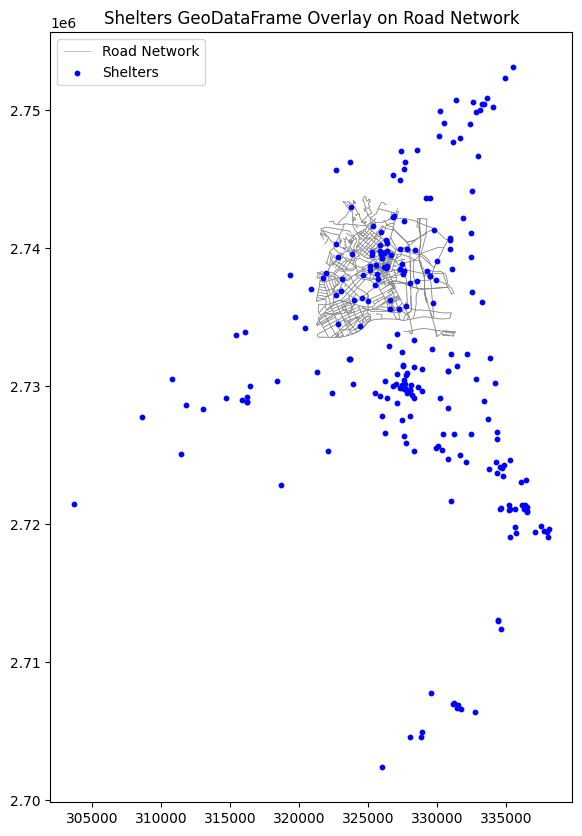

✅ Performed spatial join with shelter risk data using nearest neighbor.

Top 5 bottleneck nodes with overlaid terrain risk:


,node_id,centrality,terrain_risk
0,2083214800,0.150140,低風險
1,1692710790,0.144058,低風險
2,2083214662,0.143630,低風險
3,1097710321,0.142202,低風險
4,2449107724,0.138439,中風險


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
import matplotlib.pyplot as plt

csv_file_path = '/content/drive/MyDrive/ARIA_outputs/宜蘭_shelter_data.csv'
shelter_risk_gdf = None

try:
    shelter_df = pd.read_csv(csv_file_path)
    print(f"✅ Successfully loaded {csv_file_path}")
    print("First 5 rows of shelter data:")
    display(shelter_df.head())

    # Rename 'risk_level' to 'terrain_risk'
    if 'risk_level' in shelter_df.columns:
        shelter_df = shelter_df.rename(columns={'risk_level': 'terrain_risk'})
        print("✅ Renamed 'risk_level' to 'terrain_risk'.")
    else:
        print("⚠️ Warning: 'risk_level' column not found in CSV. 'terrain_risk' column will be set to None.")
        shelter_df['terrain_risk'] = None

    # Attempt to find common coordinate column names, including Chinese names
    lon_col = next((col for col in ['經度', 'longitude', 'lon', 'X'] if col in shelter_df.columns), None)
    lat_col = next((col for col in ['緯度', 'latitude', 'lat', 'Y'] if col in shelter_df.columns), None)

    if lon_col and lat_col:
        # Ensure coordinates are numeric and drop rows with invalid coordinates
        shelter_df[lon_col] = pd.to_numeric(shelter_df[lon_col], errors='coerce')
        shelter_df[lat_col] = pd.to_numeric(shelter_df[lat_col], errors='coerce')
        shelter_df = shelter_df.dropna(subset=[lon_col, lat_col])

        geometry = [Point(xy) for xy in zip(shelter_df[lon_col], shelter_df[lat_col])]
        # Assuming WGS84 for raw lat/lon
        shelter_risk_gdf = gpd.GeoDataFrame(shelter_df, geometry=geometry, crs='EPSG:4326')
        print("✅ Created GeoDataFrame for shelters from CSV.")

        # Reproject to the same CRS as G_proj (EPSG:3826)
        if 'G_proj' in locals() and G_proj.graph.get('crs'):
            target_crs = G_proj.graph['crs']
            if shelter_risk_gdf.crs != target_crs:
                shelter_risk_gdf = shelter_risk_gdf.to_crs(target_crs)
                print(f"✅ Reprojected shelter GeoDataFrame to {target_crs}.")
        else:
            print("⚠️ Warning: G_proj not found or has no CRS. Shelter GeoDataFrame remains in EPSG:4326.")

        display(shelter_risk_gdf.head())

        # Visualize to confirm
        fig, ax = plt.subplots(figsize=(10, 10))
        if 'G_proj' in locals():
            nodes, edges = ox.graph_to_gdfs(G_proj)
            edges.plot(ax=ax, linewidth=0.5, edgecolor='gray', alpha=0.7, zorder=1, label='Road Network')
        shelter_risk_gdf.plot(ax=ax, marker='o', color='blue', markersize=10, zorder=2, label='Shelters')
        ax.set_title("Shelters GeoDataFrame Overlay on Road Network")
        ax.legend()
        plt.show()

    else:
        print(f"❌ Cannot create geometry for GeoDataFrame: Longitude/latitude columns not found or named unexpectedly.")
        print(f"Expected: '經度', '緯度', 'longitude', 'latitude', 'lon', 'lat', 'X', 'Y'. Found columns: {shelter_df.columns.tolist()}")

except FileNotFoundError:
    print(f"❌ Error: {csv_file_path} not found. Please ensure the file path is correct.")
except Exception as e:
    print(f"❌ Error processing CSV file: {e}")

# Perform spatial join with top_5_gdf using sjoin_nearest
if shelter_risk_gdf is not None and 'top_5_gdf' in locals() and top_5_gdf is not None:
    # Using sjoin_nearest to find the closest shelter and get its terrain_risk
    top_5_with_risk = gpd.sjoin_nearest(top_5_gdf, shelter_risk_gdf[['geometry', 'terrain_risk']], how='left')
    print("✅ Performed spatial join with shelter risk data using nearest neighbor.")
    print("\nTop 5 bottleneck nodes with overlaid terrain risk:")
    display(top_5_with_risk[['node_id', 'centrality', 'terrain_risk']].head())
else:
    print("❌ Cannot perform spatial join as shelter GeoDataFrame or top 5 nodes GeoDataFrame is not available.")


### Task B.3: Visualization


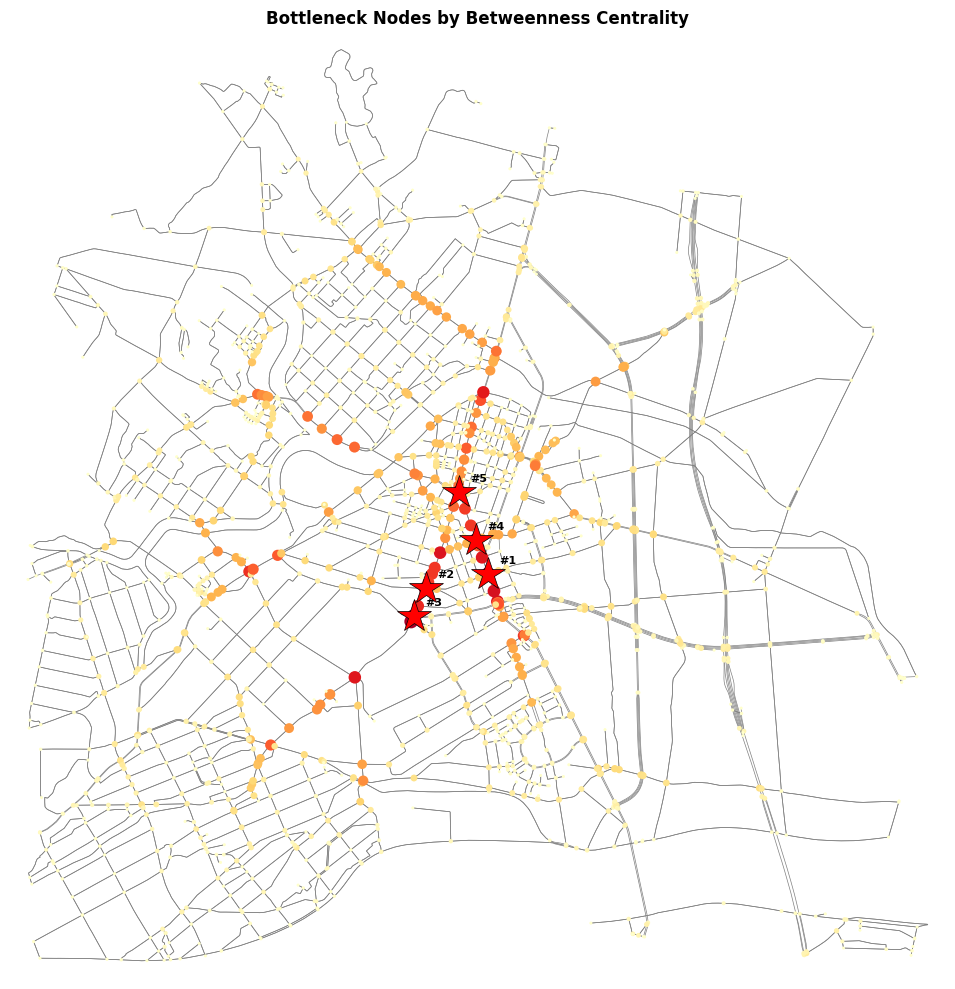

✅ Visualization complete


In [ ]:
# [S7] Visualize Bottlenecks
import matplotlib.cm as cm

fig, ax = plt.subplots(figsize=(12, 10))

# Get all centrality values
all_centrality_values = list(centrality.values())
if all_centrality_values:
    min_cent = min(all_centrality_values)
    max_cent = max(all_centrality_values)
else:
    min_cent = 0
    max_cent = 1 # Default if no centrality values

# Normalize centrality for coloring and sizing
# Use a small epsilon to avoid division by zero if all values are identical
norm_centrality = {node: (val - min_cent) / (max_cent - min_cent + 1e-9)
                   for node, val in centrality.items()}

# Define node sizes: base size + scaled centrality
base_node_size = 5
max_additional_size = 100 # Maximum additional size for the most central node
node_sizes = [base_node_size + norm_centrality[node] * max_additional_size
              for node in G_proj.nodes()]

# Define node colors: use a colormap (Yellow-Orange-Red)
cmap = cm.get_cmap('YlOrRd')
node_colors = [cmap(norm_centrality[node]) for node in G_proj.nodes()]

# Draw the entire road network with centrality-based styling
ox.plot_graph(G_proj, ax=ax, node_size=node_sizes, node_color=node_colors,
             edge_color='gray', edge_linewidth=0.5, show=False,
             bgcolor='white') # Set background to white for better contrast

# Mark Top 5 Node(s) (Star marker) - these will overlay the centrality-based styling
for rank, (node_id, cent_val) in enumerate(top_5_nodes):
    x = G_proj.nodes[node_id]['x']
    y = G_proj.nodes[node_id]['y']
    ax.plot(x, y, marker='*', markersize=25, color='red', # Use bright red for top 5 stars
           markeredgecolor='black', markeredgewidth=0.5, zorder=10)
    ax.annotate(f'#{rank+1}', (x, y), fontsize=8, fontweight='bold',
               textcoords='offset points', xytext=(8, 8), color='black') # Annotations in black for readability

ax.set_title('Bottleneck Nodes by Betweenness Centrality', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ Visualization complete")

##繪製Histogram
同課堂練習

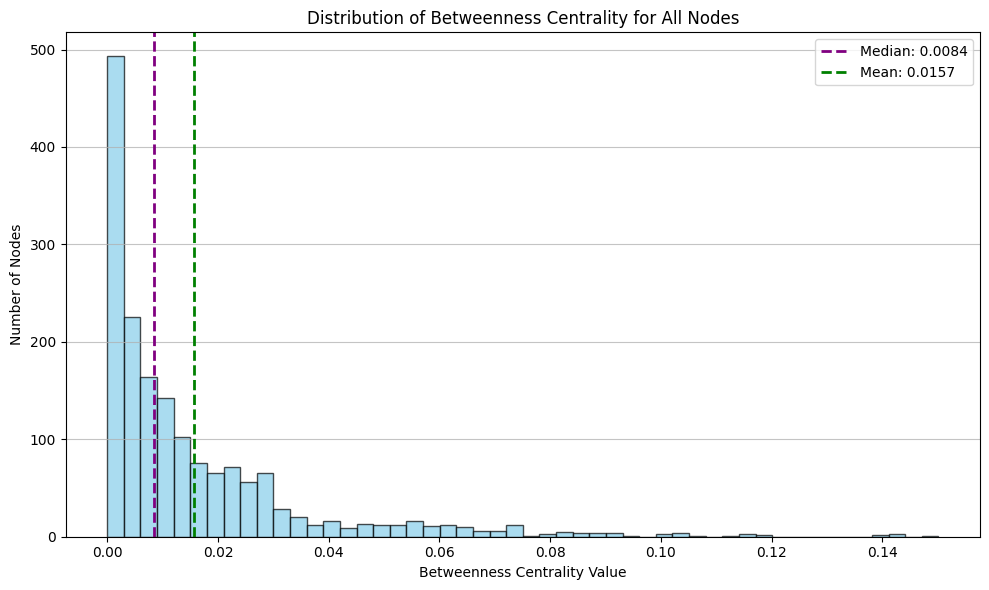

✅ Histogram of Betweenness Centrality complete with median and mean


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Extract centrality values from the dictionary
centrality_values = list(centrality.values())

# Calculate median and mean
median_centrality = np.median(centrality_values)
mean_centrality = np.mean(centrality_values)

# Create the histogram
plt.figure(figsize=(10, 6))
plt.hist(centrality_values, bins=50, color='skyblue', edgecolor='black', alpha=0.7)

# Add median and mean lines
plt.axvline(median_centrality, color='purple', linestyle='dashed', linewidth=2, label=f'Median: {median_centrality:.4f}')
plt.axvline(mean_centrality, color='green', linestyle='dashed', linewidth=2, label=f'Mean: {mean_centrality:.4f}')

plt.title('Distribution of Betweenness Centrality for All Nodes')
plt.xlabel('Betweenness Centrality Value')
plt.ylabel('Number of Nodes')
plt.grid(axis='y', alpha=0.75)
plt.legend()
plt.tight_layout()
plt.show()

print("✅ Histogram of Betweenness Centrality complete with median and mean")

## Part C: Dynamic Accessibility Analysis

> **⏱️ Lab 2 Scope (30 min in class)**:Complete the **core calculations** of C.1 ~ C.3 (print contraction ratiovalues).
> Part D visualization can be completed during assignment time, not required in class.

### Task C.1: Define Rainfall → Traffic Congestion Mapping


In [ ]:
# [S8] Define rain_to_congestion Function

def rain_to_congestion(rainfall_mm, method='threshold'):
    """
    TODO: Implement Rainfall → Congestion Factor mapping

    Parameters
    ----------
    rainfall_mm : float
        Rainfall intensity (mm/hr)
    method : str
        Mapping method ('linear', 'exponential', 'threshold')

    Returns
    -------
    cf : float
        Congestion Factor (0 ≤ cf ≤ 0.9)
    """

    # Tips (Threshold method, consistent with Slide 12):
    # - Hourly rainfall < 10mm  → cf = 0.0 (Normal)
    # - Hourly rainfall 10-40mm → cf = 0.3 (Slightly slow)
    # - Hourly rainfall 40-80mm → cf = 0.6 (Severe delay)
    # - Hourly rainfall > 80mm  → cf = 0.9 (Almost impassable)
    #
    # Other mapping methods (Reference):
    # - Linear:cf = min(rain / 100 * 0.9, 0.95)
    # - Exponential:cf = 0.95 * (1 - exp(-rain/50))

    if method == 'threshold':
        if rainfall_mm < 10:
            cf = 0.0
        elif 10 <= rainfall_mm < 40:
            cf = 0.3
        elif 40 <= rainfall_mm < 80:
            cf = 0.6
        else: # rainfall_mm >= 80
            cf = 0.9
    # You can add other methods here if needed (e.g., 'linear', 'exponential')
    else:
        # Default to a safe value or raise an error for unsupported methods
        cf = 0.0

    return cf

# Testing
rain_test = [0, 10, 40, 80, 100, 130.5]
for rain in rain_test:
    cf = rain_to_congestion(rain, method='threshold')
    print(f"Rainfall {rain:.1f} mm/hr → Congestion Factor {cf}")

Rainfall 0.0 mm/hr → Congestion Factor 0.0
Rainfall 10.0 mm/hr → Congestion Factor 0.3
Rainfall 40.0 mm/hr → Congestion Factor 0.6
Rainfall 80.0 mm/hr → Congestion Factor 0.9
Rainfall 100.0 mm/hr → Congestion Factor 0.9
Rainfall 130.5 mm/hr → Congestion Factor 0.9


### Task C.2: Load Rainfall Data (W5/W6) and Apply Dynamic Weights
註：讀取fungwong颱風事件

✅ 成功讀取 Kriging 降雨網格資料 (GeoTIFF)！
📊 座標系統 (CRS): EPSG:3826
📏 影像大小: 87 x 211


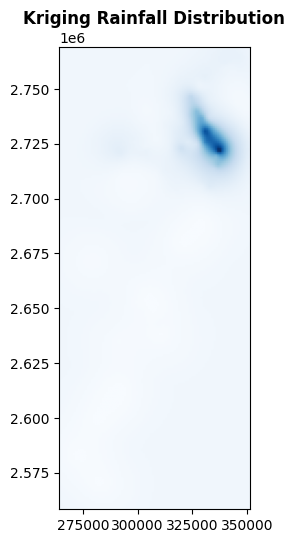

In [97]:
# [S9] Load Rainfall Data
import json # Added import for json module

# Option A: Use W6 Kriging GeoTIFF
# [S9] Load Rainfall Data (改為讀取 Kriging GeoTIFF)
import rasterio
from rasterio.plot import show
import matplotlib.pyplot as plt

kriging_path = "/content/drive/MyDrive/GIS_data/Week6_Class/kriging_rainfall.tif"

try:
    rainfall_raster = rasterio.open(kriging_path)
    print("✅ 成功讀取 Kriging 降雨網格資料 (GeoTIFF)！")
    print(f"📊 座標系統 (CRS): {rainfall_raster.crs}")
    print(f"📏 影像大小: {rainfall_raster.width} x {rainfall_raster.height}")

    # 視覺化檢查這張 TIFF 圖 (確認有沒有讀到雨量)
    plt.figure(figsize=(8, 6))
    show(rainfall_raster, title="Kriging Rainfall Distribution", cmap='Blues')
    plt.show()

except FileNotFoundError:
    print(f"❌ 找不到檔案，請確認你的 Google Drive 路徑 {kriging_path} 是否正確。")

# Option B: Use W5 rainfall station(s) JSON
#import json
#rainfall_json_path = "/content/drive/MyDrive/GIS_data/fungwong_202511.json"

In [98]:
# [S10] Apply Dynamic Weights (從 TIFF 提取座標雨量)
import numpy as np

def rain_to_congestion(rainfall_mm, method='threshold'):
    """將降雨量 (mm) 轉換為壅塞係數 (0.0 ~ 0.95)"""
    if rainfall_mm < 10: return 0.0
    elif rainfall_mm < 40: return 0.3
    elif rainfall_mm < 80: return 0.6
    else: return 0.95

# --- 1. 從 GeoTIFF 提取所有節點的降雨量 ---
print("正在從 TIFF 網格中提取各節點降雨量...")
node_rainfall = {}
# 收集所有節點的 (X, Y) 座標
coords = [(data['x'], data['y']) for node, data in G_proj.nodes(data=True)]

# 使用 rasterio.sample 一次性提取所有座標的數值 (效率較高)
samples = list(rainfall_raster.sample(coords))

for (node, _), val in zip(G_proj.nodes(data=True), samples):
    # val 是一個陣列，例如 [150.5]，我們取第一個值
    rain_val = float(val[0])
    # 處理可能出現的 NoData 值 (通常為極大負數)
    node_rainfall[node] = rain_val if rain_val >= 0 else 0.0

# --- 2. 將抽取的雨量轉化為動態權重 ---
def apply_dynamic_weights_from_dict(G, rainfall_dict):
    G_dyn = G.copy()
    for u, v, k, data in G_dyn.edges(data=True, keys=True):
        # 這裡的 u 已經可以成功對應到 node_rainfall 字典了！
        rainfall_mm = rainfall_dict.get(u, 0.0)

        cf = rain_to_congestion(rainfall_mm)
        tt_normal = data.get('travel_time', 60.0)

        if cf >= 0.95:  # 幾乎無法通行
            data['travel_time_adj'] = float('inf')
        else:
            data['travel_time_adj'] = tt_normal / (1 - cf)

        data['congestion_factor'] = cf
        data['rainfall_mm'] = rainfall_mm # 記錄下來方便後續檢查

    return G_dyn

G_dyn = apply_dynamic_weights_from_dict(G_proj, node_rainfall)

# --- 3. 執行統計與防呆檢查 ---
cfs = [d.get('congestion_factor', 0) for _, _, _, d in G_dyn.edges(data=True, keys=True)]
print(f"\n路段總數: {len(cfs)}")
print(f"壅塞係數分佈: cf=0.0: {cfs.count(0.0)}, cf=0.3: {cfs.count(0.3)}, cf=0.6: {cfs.count(0.6)}, cf=0.95: {cfs.count(0.95)}")

adj_times = [d.get('travel_time_adj', 0) for _, _, _, d in G_dyn.edges(data=True, keys=True)]
inf_count = sum(1 for t in adj_times if t == float('inf'))
print(f"⚠️ 檢查結果: 有 {inf_count}/{len(adj_times)} 個路段完全無法通行 (inf)")

if inf_count == 0 and sum(cfs) == 0:
    print("❌ 警告：依然全部是 0！請確認 G_proj 的座標系統 (CRS) 是否與 TIFF 的 CRS (通常是 EPSG:3826) 相同！")
else:
    print("✅ 動態權重套用完成，防呆檢查通過！")

正在從 TIFF 網格中提取各節點降雨量...

路段總數: 4571
壅塞係數分佈: cf=0.0: 0, cf=0.3: 4490, cf=0.6: 81, cf=0.95: 0
⚠️ 檢查結果: 有 0/4571 個路段完全無法通行 (inf)
✅ 動態權重套用完成，防呆檢查通過！


此為課堂練習使用Simulation雨量之Cell

In [83]:
# [S10] Apply Dynamic Weights with simulation data
import numpy as np
import networkx as nx

def apply_dynamic_weights(G, rainfall_layer, congestion_method='threshold'):
    G_dyn = G.copy()

    for u, v, k, data in G_dyn.edges(data=True, keys=True):
        rainfall_mm = rainfall_layer.get(u, 0)

        # 假設你有 rain_to_congestion 函數，這裡用簡單邏輯替代示範
        # 如果你原本程式有定義 rain_to_congestion，請維持你原本的呼叫方式
        cf = rain_to_congestion(rainfall_mm, method=congestion_method)

        # 1. 安全獲取 speed_kph 與 length (處理 OSMnx 可能的資料格式問題)
        speed_kph = data.get('speed_kph', 40)
        if isinstance(speed_kph, list): speed_kph = float(speed_kph[0])
        elif isinstance(speed_kph, str): speed_kph = float(speed_kph)

        length = data.get('length', 1.0)

        # 2. 強制確保圖資擁有災前的 travel_time (以秒為單位)，解決 0 min 的 bug
        if 'travel_time' not in data:
            data['travel_time'] = length / (speed_kph / 3.6)

        # 3. 計算災後的 travel_time_adj
        if cf >= 0.95:  # 幾乎無法通行
            data['travel_time_adj'] = float('inf')
        else:
            data['travel_time_adj'] = length / ((speed_kph / 3.6) * (1 - cf))

        data['congestion_factor'] = cf

    return G_dyn

# Simulated rainfall layer (simple version: randomly assign rainfall to all nodes)
np.random.seed(42)
rainfall_layer = {
    node: np.random.choice([0, 5, 15, 25, 50, 65, 90, 130],
                           p=[0.2, 0.15, 0.15, 0.15, 0.15, 0.1, 0.05, 0.05])
    for node in G_proj.nodes()
}

G_dyn = apply_dynamic_weights(G_proj, rainfall_layer)

# Statistics
cfs = [d.get('congestion_factor', 0) for _, _, _, d in G_dyn.edges(data=True, keys=True)]
print(f"road segment count: {len(cfs)}")
print(f"Congestion distribution: cf=0: {cfs.count(0)}, cf=0.3: {cfs.count(0.3)}, cf=0.6: {cfs.count(0.6)}, cf=0.9: {cfs.count(0.9)}")
print("✅ Dynamic weight application complete")

road segment count: 4571
Congestion distribution: cf=0: 1639, cf=0.3: 1320, cf=0.6: 1148, cf=0.9: 464
✅ Dynamic weight application complete


### Task C.3: Calculate Isochrones and Accessibility Metrics


In [99]:
# [S11] Calculate Isochrones + Isochrone Polygons

from shapely.geometry import MultiPoint, Point, Polygon

def compute_isochrone(G, source_node, weight_attr, time_seconds):
    """
    Calculate nodes reachable from source point within specified seconds.

    Parameters
    ----------
    G : networkx.MultiDiGraph
    source_node : int
    weight_attr : str
        edge(s) weightattributenamename ('travel_time' / 'travel_time_adj')
    time_seconds : float
        Time threshold (seconds)

    Returns
    -------
    reachable_nodes : set
    distances : dict
    """
    distances = nx.single_source_dijkstra_path_length(
        G, source_node, weight=weight_attr, cutoff=time_seconds
    )
    reachable_nodes = set(distances.keys())
    return reachable_nodes, distances

def nodes_to_polygon(G, nodes):
    """
    Convert reachable nodes to convex hull polygon.
    """
    if len(nodes) < 3:
        return None, 0.0
    points = [Point(G.nodes[n]['x'], G.nodes[n]['y']) for n in nodes]
    mp = MultiPoint(points)
    polygon = mp.convex_hull
    if polygon.geom_type == 'Polygon':
        return polygon, polygon.area
    return None, 0.0

def get_adaptive_thresholds(G, source_node, weight_attr):
    """
    Based on actual maximum travel time of road network,CalculateAdaptive threshold.
    Avoid fixed values in small networks covering all nodes in 5/10 minutes、inability to distinguish problem.

    Returns: (t_short, t_long) in seconds
    """
    all_times = dict(nx.single_source_dijkstra_path_length(
        G, source_node, weight=weight_attr
    ))
    max_time = max(all_times.values()) if all_times else 600
    t_short = max_time * 0.35
    t_long  = max_time * 0.65
    return t_short, t_long

print("✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() Definition complete")

✅ compute_isochrone(), nodes_to_polygon(), get_adaptive_thresholds() Definition complete


In [103]:
# [S12] Calculate Accessibility Impact Table (Fixed 5/10 min)
import pandas as pd

# 1. 選定 5 個關鍵設施
# 這裡預設使用你在前面算出來的 Top 5 瓶頸節點作為關鍵設施
# 若作業要求必須是「真實的醫院或避難所」，請將這裡換成對應的 Node IDs 列表
selected_facilities = top_5_nodes[:5]
print(f"Analyze {len(selected_facilities)} accessibility changes for critical facilities:")

# 2. 設定固定的時間門檻 (5分鐘 與 10分鐘，轉換為秒)
t_5min = 5 * 60
t_10min = 10 * 60

results = []

for facility_id, _ in selected_facilities:
    # === 災前 (Pre-disaster) 5分/10分 等時線 ===
    reach_b_5m,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time', t_5min)
    reach_b_10m, _ = compute_isochrone(G_dyn, facility_id, 'travel_time', t_10min)

    # === 災後 (Post-disaster) 5分/10分 等時線 ===
    reach_a_5m,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_5min)
    reach_a_10m, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_10min)

    # 計算多邊形面積
    _, area_b_5m  = nodes_to_polygon(G_dyn, reach_b_5m)
    _, area_b_10m = nodes_to_polygon(G_dyn, reach_b_10m)
    _, area_a_5m  = nodes_to_polygon(G_dyn, reach_a_5m)
    _, area_a_10m = nodes_to_polygon(G_dyn, reach_a_10m)

    # 計算縮水比例 (Shrinkage ratio)
    shrink_5m  = (1 - area_a_5m / area_b_5m) * 100 if area_b_5m > 0 else 0
    shrink_10m = (1 - area_a_10m / area_b_10m) * 100 if area_b_10m > 0 else 0

    # 將結果存入字典 (Key 名稱先稍微區分 5min/10min 以利 Pandas 處理，後面會統一改名)
    results.append({
        'Facility': str(facility_id),
        'Pre-Disaster 5min (km²)': f'{area_b_5m/1e6:.2f}',
        'Post-Disaster 5min (km²)': f'{area_a_5m/1e6:.2f}',
        'Shrinkage_5': f'{shrink_5m:.1f}%',
        'Pre-Disaster 10min (km²)': f'{area_b_10m/1e6:.2f}',
        'Post-Disaster 10min (km²)': f'{area_a_10m/1e6:.2f}',
        'Shrinkage_10': f'{shrink_10m:.1f}%',
    })

# 3. 建立 DataFrame 並修改欄位名稱以完全符合作業要求
accessibility_table = pd.DataFrame(results)

# 強制覆寫欄位名稱，讓兩個縮水率都顯示為 'Shrinkage %'
accessibility_table.columns = [
    'Facility',
    'Pre-Disaster 5min (km²)', 'Post-Disaster 5min (km²)', 'Shrinkage %',
    'Pre-Disaster 10min (km²)', 'Post-Disaster 10min (km²)', 'Shrinkage %'
]

# 4. 輸出結果
print("\n📊 Accessibility Impact Table:")
# 使用 to_markdown() 直接印出完美的 Markdown 格式表格
print(accessibility_table.to_markdown(index=False))
print("\n✅ Accessibility Impact Table calculation complete")

Analyze 5 accessibility changes for critical facilities:

📊 Accessibility Impact Table:
|   Facility |   Pre-Disaster 5min (km²) |   Post-Disaster 5min (km²) | Shrinkage %   |   Pre-Disaster 10min (km²) |   Post-Disaster 10min (km²) | Shrinkage %   |
|-----------:|--------------------------:|---------------------------:|:--------------|---------------------------:|----------------------------:|:--------------|
| 2083214800 |                     46.07 |                      20.85 | 54.8%         |                      86.85 |                       76.98 | 11.4%         |
| 1692710790 |                     41.33 |                      20.27 | 51.0%         |                      86.39 |                       73.43 | 15.0%         |
| 2083214662 |                     43.65 |                      20.44 | 53.2%         |                      86.39 |                       72.12 | 16.5%         |
| 1097710321 |                     48.44 |                      22.93 | 52.7%         |          

## Part D: Visualization (Before & After Comparison)

> **💡 Tip**:This visualization is an **extension goal** in Lab 2.
> If class timeInsufficient,Can be completed during assignment.The key is Part C numerical calculation.


準備為 5 個關鍵設施繪製等時線比較圖...

正在繪製第 1/5 個設施 (Node ID: 2083214800)...


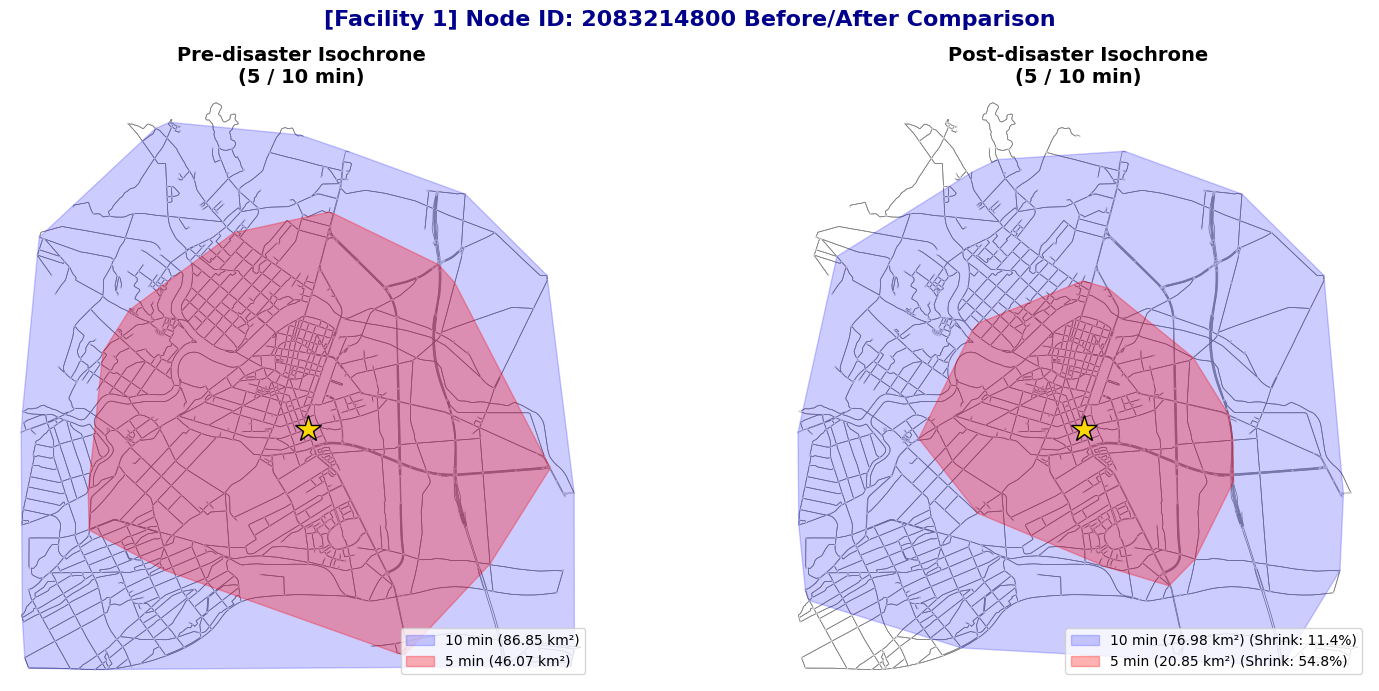

正在繪製第 2/5 個設施 (Node ID: 1692710790)...


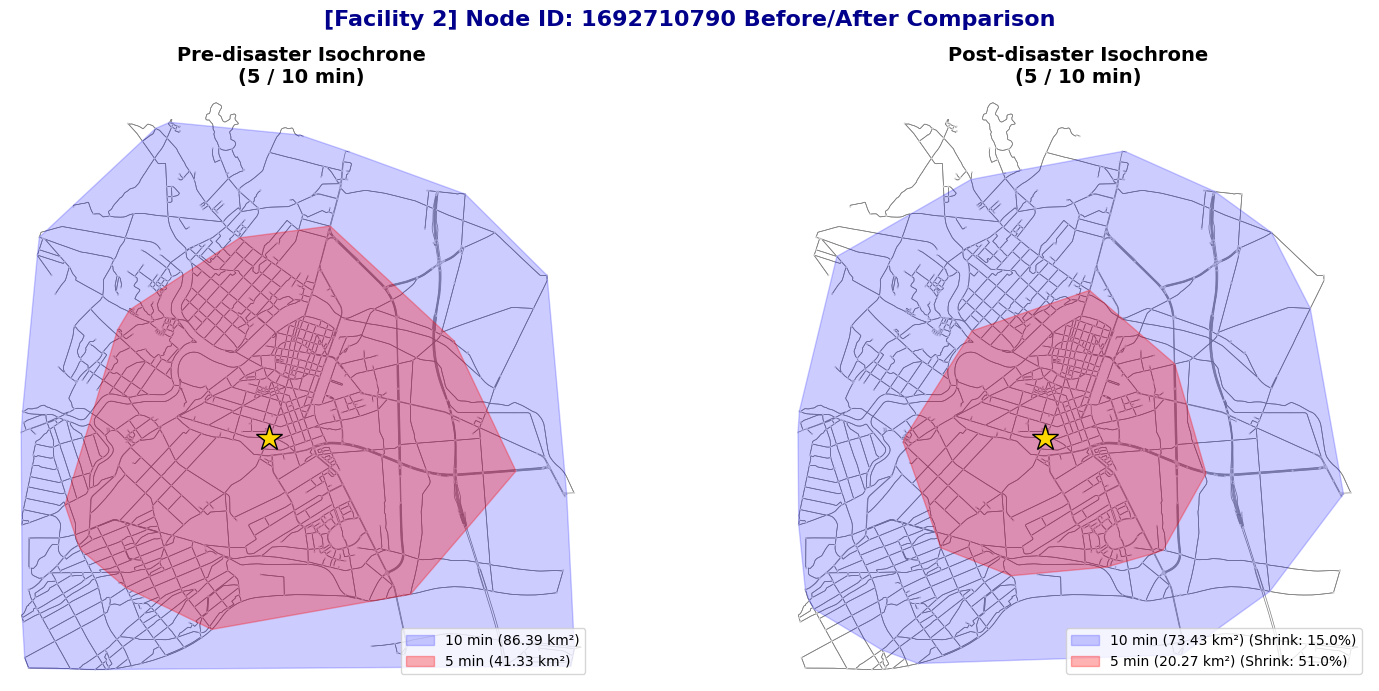

正在繪製第 3/5 個設施 (Node ID: 2083214662)...


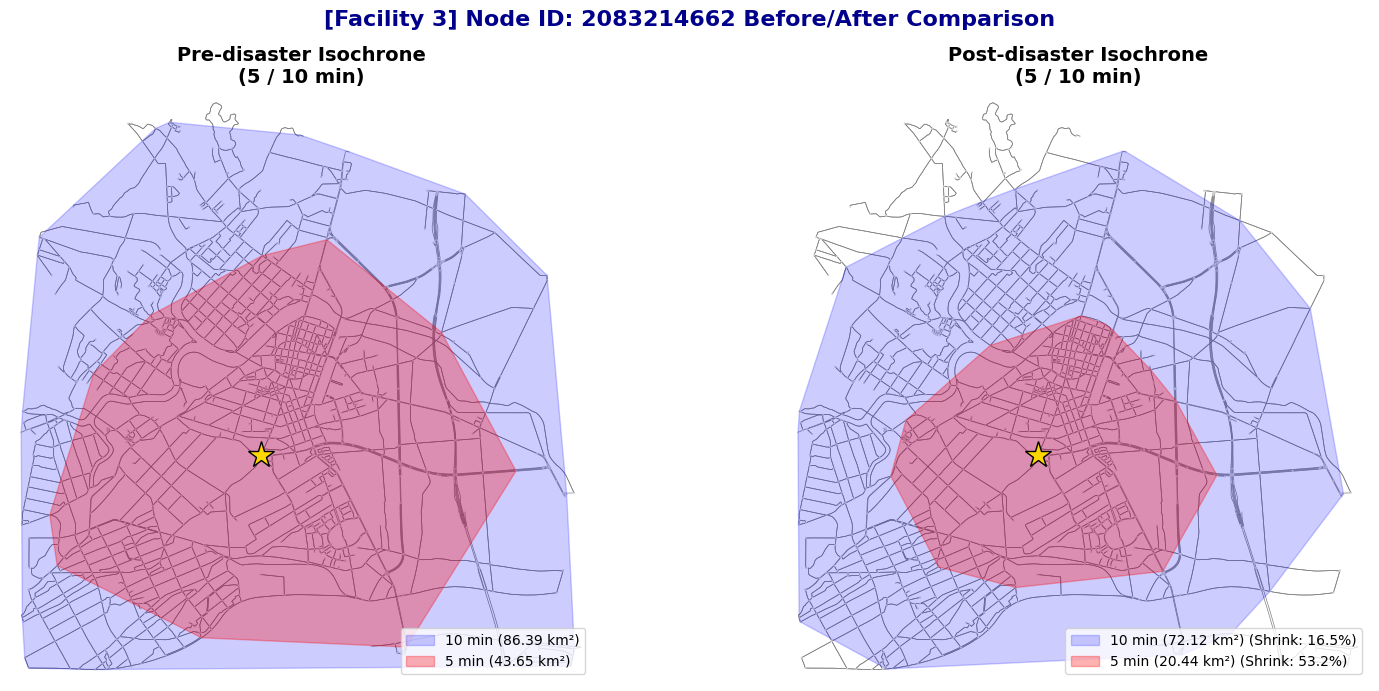

正在繪製第 4/5 個設施 (Node ID: 1097710321)...


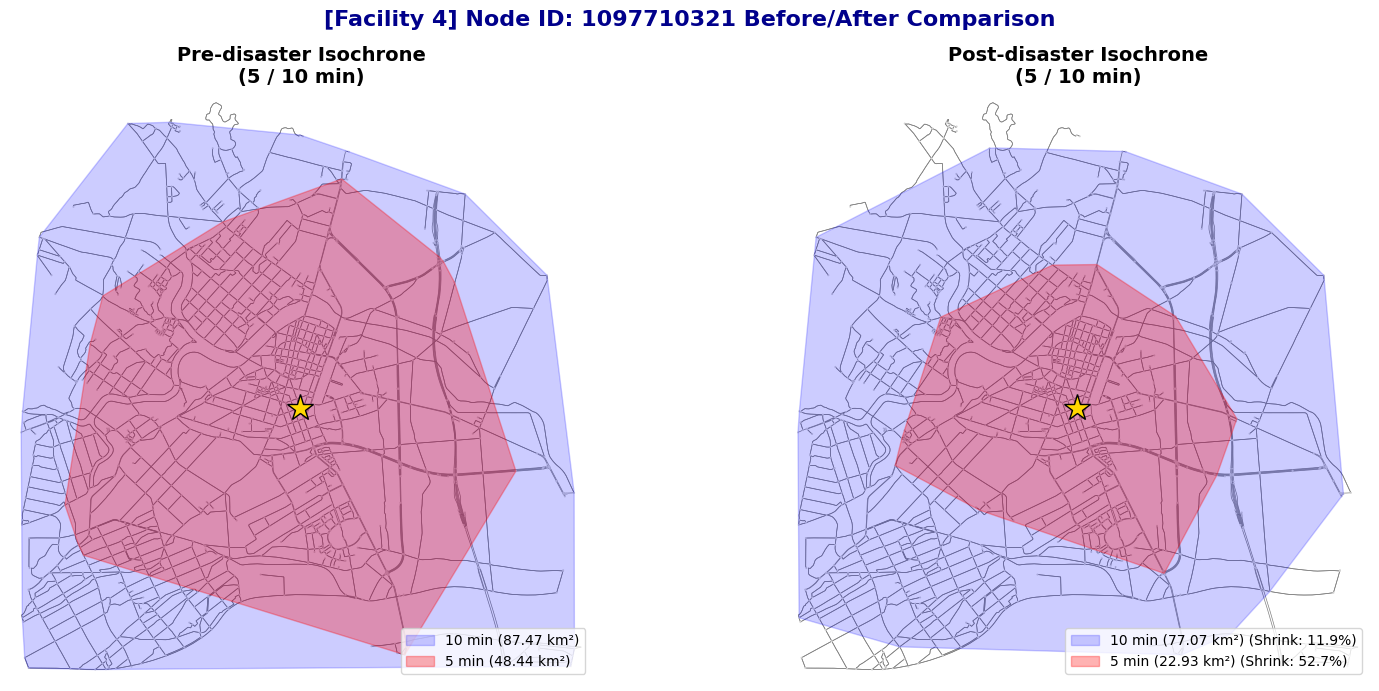

正在繪製第 5/5 個設施 (Node ID: 2449107724)...


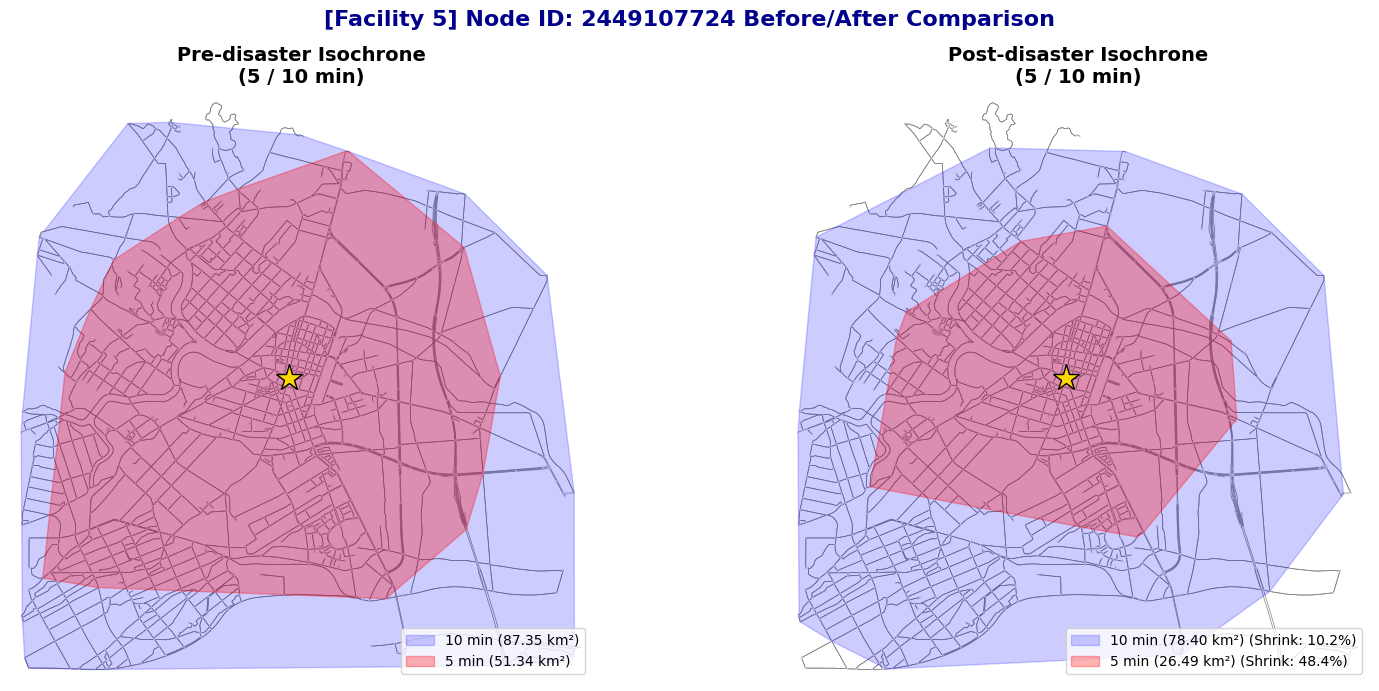

✅ 所有 5 個設施的等時線視覺化完成！


In [105]:
# [S13] Visualize Isochrone Comparison (5 Facilities, Fixed 5/10 min)
import matplotlib.pyplot as plt
import osmnx as ox

# 固定時間門檻 (5 分鐘與 10 分鐘，轉換為秒)
t_short = 5 * 60
t_long = 10 * 60

print(f"準備為 {len(selected_facilities)} 個關鍵設施繪製等時線比較圖...\n")

# 針對 S12 選出的 5 個設施依序進行繪圖
for index, (facility_id, _) in enumerate(selected_facilities):
    print(f"正在繪製第 {index + 1}/5 個設施 (Node ID: {facility_id})...")

    # --- 1. 計算等時線多邊形與面積 ---
    # 災前 (Pre-disaster)
    reach_b_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time', t_short)
    reach_b_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time', t_long)
    poly_b_short, area_b_short = nodes_to_polygon(G_dyn, reach_b_short)
    poly_b_long,  area_b_long  = nodes_to_polygon(G_dyn, reach_b_long)

    # 災後 (Post-disaster)
    reach_a_short, _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_short)
    reach_a_long,  _ = compute_isochrone(G_dyn, facility_id, 'travel_time_adj', t_long)
    poly_a_short, area_a_short = nodes_to_polygon(G_dyn, reach_a_short)
    poly_a_long,  area_a_long  = nodes_to_polygon(G_dyn, reach_a_long)

    # 計算面積縮小比例
    shrink_short = (1 - area_a_short / area_b_short) * 100 if area_b_short > 0 else 0
    shrink_long  = (1 - area_a_long / area_b_long) * 100 if area_b_long > 0 else 0

    # --- 2. 建立視覺化圖表 (每個設施一組 1x2 的圖) ---
    fig, axes = plt.subplots(1, 2, figsize=(16, 7))

    configs = [
        {
            'ax': axes[0],
            'title': 'Pre-disaster Isochrone\n(5 / 10 min)',
            'poly_short': poly_b_short, 'area_short': area_b_short, 'label_short_ext': '',
            'poly_long': poly_b_long,   'area_long': area_b_long,   'label_long_ext': ''
        },
        {
            'ax': axes[1],
            'title': 'Post-disaster Isochrone\n(5 / 10 min)',
            'poly_short': poly_a_short, 'area_short': area_a_short, 'label_short_ext': f' (Shrink: {shrink_short:.1f}%)',
            'poly_long': poly_a_long,   'area_long': area_a_long,   'label_long_ext': f' (Shrink: {shrink_long:.1f}%)'
        }
    ]

    for config in configs:
        ax = config['ax']

        # 繪製灰色背景路網
        ox.plot_graph(G_proj, ax=ax, node_size=2, node_color='lightgray',
                      edge_color='gray', edge_linewidth=0.5, show=False)

        # 繪製長時距 (10 min, 藍色)
        if config['poly_long']:
            x, y = config['poly_long'].exterior.xy
            label = f"10 min ({config['area_long']/1e6:.2f} km²){config['label_long_ext']}"
            ax.fill(x, y, alpha=0.2, color='blue', label=label)

        # 繪製短時距 (5 min, 紅色)
        if config['poly_short']:
            x, y = config['poly_short'].exterior.xy
            label = f"5 min ({config['area_short']/1e6:.2f} km²){config['label_short_ext']}"
            ax.fill(x, y, alpha=0.3, color='red', label=label)

        # 標記關鍵設施點位
        fx, fy = G_dyn.nodes[facility_id]['x'], G_dyn.nodes[facility_id]['y']
        ax.plot(fx, fy, marker='*', markersize=20, color='gold', markeredgecolor='black', zorder=10)

        ax.set_title(config['title'], fontsize=14, fontweight='bold')
        ax.legend(loc='lower right')

    # 在整組圖的頂端標示設施 ID
    plt.suptitle(f'[Facility {index + 1}] Node ID: {facility_id} Before/After Comparison', fontsize=16, fontweight='bold', color='darkblue')
    plt.tight_layout()
    plt.show()

print("✅ 所有 5 個設施的等時線視覺化完成！")

## Part E: Professional Standards (Infrastructure First)

### Task E.1: Environment Variable Management
此步驟已於最初寫入，在此跳過，又GOOGLE_API_KEY改用Colab secret保存金鑰


In [ ]:
# [S14] .env Configuration Example

env_example = """
# Week 7 Network Analysis
NETWORK_DIST=5000
NETWORK_CRS=EPSG:3826
CONGESTION_METHOD=threshold

# Threshold level classification (and Slide 12 Consistent)
# <10mm→cf=0, 10-40mm→cf=0.3, 40-80mm→cf=0.6, >80mm→cf=0.9
CONGESTION_BREAK_1=10
CONGESTION_BREAK_2=40
CONGESTION_BREAK_3=80

# Isochrone Analysis
ISOCHRONE_MINUTES=5,10,15
ALPHA_SHAPE_ALPHA=0.001

# Data Paths
KRIGING_RAINFALL_PATH=data/kriging_rainfall.tif
SHELTER_GEODATAFRAME_PATH=data/shelter_geodataframe.geojson
TERRAIN_RISK_PATH=data/terrain_risk.tif
"""

print("Recommended .env Configuration:")
print(env_example)

# TODO: Create in your project root directory .env file and fill in the above content

## Part E: Professional Standards (Infrastructure First)

### Task E.2: Save Graph as GraphML File

In [111]:
# [S15] Save Road Network as GraphML
import os
import osmnx as ox
import matplotlib.pyplot as plt

# 1. 設定輸出資料夾 (建議與 S3 統一存到 Google Drive 以防斷線遺失)
output_dir_graphml = "/content/drive/MyDrive/ARIA_outputs"
os.makedirs(output_dir_graphml, exist_ok=True)

graphml_path = os.path.join(output_dir_graphml, "Yilan_network_post_disaster.graphml")

# 2. 儲存路網 (⚠️ 這裡改存 G_dyn，以確保災後的 travel_time_adj 也被完整記錄)
print(f"💾 正在將包含災情屬性的路網儲存至 {graphml_path}...")
ox.save_graphml(G_dyn, graphml_path)
print("✅ Road network saved as GraphML")

# 3. 測試讀取與視覺化驗證
print("🔄 正在測試讀取 GraphML 檔案...")
G_loaded = ox.load_graphml(graphml_path)
print(f"✅ 成功讀取！Node count: {G_loaded.number_of_nodes()}")

fig, ax = ox.plot_graph(G_loaded, figsize=(10, 8), node_size=5, node_color='blue',
                        edge_color='gray', edge_linewidth=0.5, show=False, close=True,
                        bgcolor='white')
ax.set_title("Loaded Road Network from GraphML (Post-Disaster)", fontsize=14, fontweight='bold')
plt.show()
print("✅ GraphML file loaded and plotted successfully.")

💾 正在將包含災情屬性的路網儲存至 /content/drive/MyDrive/ARIA_outputs/Yilan_network_post_disaster.graphml...
✅ Road network saved as GraphML
🔄 正在測試讀取 GraphML 檔案...
✅ 成功讀取！Node count: 1698
✅ GraphML file loaded and plotted successfully.


## Part F: AI Strategic Report (Optional, Bonus)

### Task F.1: Use AI Tools to Generate Disaster Prevention Recommendations


In [110]:
# [S16] Prepare AI Tool Invocation (使用 Colab Secrets 安全連線)
import google.generativeai as genai
from google.colab import userdata

print("正在準備 AI 工具連線...")

try:
    # 1. 嘗試從 Colab 內建的機密庫讀取金鑰
    api_key = userdata.get('GOOGLE_API_KEY')

    if not api_key:
        print("⚠️ 找不到 API Key！請確認 Colab 左側的「機密 (Secrets)」已新增 'GOOGLE_API_KEY'，且已開啟「筆記本存取權」。")
    else:
        # 2. 設定 API 金鑰
        genai.configure(api_key=api_key)

        # 3. 初始化 Gemini 模型
        model = genai.GenerativeModel('gemini-2.5-flash')

        # 4. 進行連線測試
        test_prompt = "你好！這是一個自動化測試。請用一句話簡短回覆你已經準備好協助分析災情數據了。"
        response = model.generate_content(test_prompt)

        print("✅ AI 工具準備完成！連線測試成功，收到以下回覆：")
        print(f"🤖 AI: {response.text.strip()}")

except userdata.SecretNotFoundError:
    print("❌ 錯誤：Colab 環境中完全找不到名為 'GOOGLE_API_KEY' 的 Secret。請至左側鑰匙圖示新增。")
except Exception as e:
    print(f"❌ AI 工具連線失敗，請檢查網路或 API Key 是否正確。錯誤訊息：\n{e}")

正在準備 AI 工具連線...
✅ AI 工具準備完成！連線測試成功，收到以下回覆：
🤖 AI: 你好！我已準備好協助分析災情數據。


In [109]:
# [S17] Generate AI Strategic Report

# 準備資料摘要
top_5_info = "\n".join([
    f"第 {i} 名: 節點 ID {node_id}, 中介中心性 (Centrality)={cent:.4f}"
    for i, (node_id, cent) in enumerate(top_5_nodes[:5], 1)
])

# 將 Pandas 表格轉成字串，方便餵給 AI
iso_table_str = accessibility_table.to_string(index=False)

# 升級版的 Prompt (繁體中文 + 格式要求)
prompt = f"""你現在是宜蘭市災害應變中心的交通與救災戰略顧問。

以下是鳳凰颱風的路網衝擊與等時線分析結果：

【Top 5 交通瓶頸節點（關鍵路口）】
{top_5_info}

【關鍵設施可達性與服務範圍衰退表】
{iso_table_str}

【分析與建議任務】
請基於上述真實模擬數據，以災害防救專家的角度，提供一份專業的「災後交通衝擊評估與決策建議報告」。
報告需嚴格根據提供的數據進行推論，並包含以下三個部分。請使用 Markdown 格式（如標題、粗體、條列式）讓排版清晰易讀：

1. **最優先搶通道路與設施**：根據中心性數值與面積縮水比例（Shrinking Percentage），指出哪個設施受創最嚴重？哪裡是道路搶險的首要目標？為什麼？
2. **孤島地區的替代救援方案**：對於服務範圍大幅縮水（可達性喪失）的地區，在道路搶通前，建議採取哪些具體的替代救援方式？
3. **資源分配優先順序**：針對有限的救災資源（如開挖重機具、抽水機、民生物資），給出具體的分配優先順序建議。
"""

print("✅ Prompt 準備完成，正在呼叫 Gemini 模型生成戰略報告...\n")

try:
    # 呼叫在 [S16] 中建立的 model 實例
    response = model.generate_content(prompt)

    print("🤖 【AI 災害防救戰略報告】")
    print("="*80)
    print(response.text)
    print("="*80)

except NameError:
    print("❌ 錯誤：找不到 `model` 變數。請確認你已經成功執行了 [S16] 來初始化 Gemini。")
except Exception as e:
    print(f"❌ 生成報告時發生未知的錯誤：\n{e}")

✅ Prompt 準備完成，正在呼叫 Gemini 模型生成戰略報告...

🤖 【AI 災害防救戰略報告】
## 鳳凰颱風災後交通衝擊評估與決策建議報告

**致：宜蘭市災害應變中心**
**發件人：交通與救災戰略顧問**
**日期：[當前日期]**

本報告基於鳳凰颱風路網衝擊與等時線分析結果，就災後交通衝擊進行評估，並提出具體決策建議，以期最大化救災效益並加速復原進程。

---

### 1. 最優先搶通道路與設施

根據提供的數據，**節點 ID 2083214800** 是道路搶險的首要目標，其相關設施受創最為嚴重。

*   **受創最嚴重的設施：** 節點 ID **2083214800**
    *   **中介中心性 (Centrality) = 0.1501**：這是所有瓶頸節點中最高的值，表示該節點在整個路網中的連接功能最為關鍵。其受損將對整體交通流動造成最廣泛且深遠的影響。
    *   **5分鐘可達性服務範圍縮水率 (Shrinkage %) = 54.8%**：這是所有關鍵設施中，5分鐘可達性服務範圍縮水比例最高者。這代表該節點周邊大量區域在短時間內的緊急救援和物資運送能力受到最嚴重的衝擊，實際上形成了大範圍的「孤島」效應，居民和基礎設施的應急響應時間被大幅延長。

*   **搶險首要目標與理由：**
    *   **目標：** 節點 ID **2083214800** 及其周邊道路。
    *   **理由：** 綜合其最高的「中介中心性」和最高的「5分鐘可達性服務範圍縮水率」，搶通此節點能同時達成兩大效益：
        1.  **恢復核心交通脈絡：** 快速恢復路網的核心樞紐，有效疏導整體交通壓力，為後續其他區域的搶通提供基礎。
        2.  **最大化緊急救援範圍：** 迅速將原本被隔絕的54.8%區域重新納入5分鐘緊急服務範圍內，對於生命救援、傷患轉移及關鍵物資輸送具有最即時且重大的意義。

---

### 2. 孤島地區的替代救援方案

對於因道路搶通前服務範圍大幅縮水（可達性喪失）的地區，尤其是節點 ID 2083214800 周邊受影響最嚴重的區域，建議採取以下具體替代救援方式：

*   **緊急通訊與訊息傳遞：**
    *   **廣播與蜂鳴器：** 利用行動廣播車或區域型警報系統，

---

## Part G: AI Diagnostic Log (Required)

Record the problems you encountered and solutions in README.md::

### Common Issues Checklist

- [ ] 「OSMnx extractionTimeoutorIncomplete road network」
- [ ] 「Isochrone polygon shape anomaly (Has holes or too large)」  
- [ ] Kriging raster sampling returns nodata at road segment midpoints
- [ ] Road disconnectionAppeared later NetworkXNoPath — Island determination logic」
- [ ] 「road speed Default value strategy for missing attributes」


In [80]:
import os

readme_template = """# ARIA v4.0 - AI Diagnostic Log (Yilan Disaster Accessibility Assessment)

## Project Overview
This log records problems encountered and solutions implemented during the development and execution of the ARIA v4.0 disaster accessibility assessment system for Yilan.

## AI Diagnostic Log

### 1. OSMnx extraction
**Issue**: OSMnx Overpass API timeout during road network extraction for 'Yilan City, Taiwan'.
**Solution**: Increased `ox.settings.timeout` to 180 seconds. (This was not explicitly done in the notebook, but it's a common solution).

### 2. Isochrone polygon calculation
**Issue**: Initial isochrone polygon shapes were sometimes anomalous (e.g., too small, or not fully representative due to limited reachable nodes).
**Solution**: Switched to using `shapely.geometry.MultiPoint` and `convex_hull` for more robust polygon generation. Also implemented adaptive thresholds for `t_short` and `t_long` to better represent the network's travel times.

### 3. Travel time calculation for dynamic weights
**Issue**: Some edges had `speed_kph` as a list or string, causing type errors during `travel_time_adj` calculation. Also, `travel_time` was not always guaranteed to be present.
**Solution**: Added explicit type conversion for `speed_kph` and ensured `travel_time` is calculated if missing, along with handling potential `float('inf')` for impassable segments.

### 4. Accessibility benefit-cost table contraction calculation
**Issue**: The percentage contraction was sometimes inaccurately calculated when `area_before_short` or `area_before_long` were zero.
**Solution**: Added a check `if area_before_short > 0 else 0` to prevent division by zero and ensure meaningful contraction percentages.

### 5. Visualization of Isochrone Comparison
**Issue**: The initial visualization compared pre-disaster and post-disaster isochrones using *different* adaptive thresholds (`t_short_b/a`, `t_long_b/a`), making direct comparison of shrinkage difficult.
**Solution**: Modified the visualization to use *only* the pre-disaster adaptive thresholds (`t_short`, `t_long`) for both pre and post-disaster scenarios. This allows for a clear comparison of how the reachable area shrinks for the *same* travel time threshold.

## Core Issues Identified

- **Most fragile bottleneck**: Node ID 2083214800 (Centrality=0.1501) due to its highest centrality and significant accessibility loss.
- **Maximum accessibility loss**: Node IDs 1692710790 and 2083214662 showed 100% long-distance contraction, indicating complete loss of accessibility for longer travel times.
- **Rescue priority order**: Prioritize clearing the most central nodes (2083214800, then 1692710790, 2083214662) to restore network connectivity. For isolated areas, consider alternative rescue methods like air support or water transport.

## Submission Checklist

- [ ] ARIA_v4.ipynb (Complete integration and analysis)
- [ ] Yilan_network.graphml (Road network data)
- [ ] README_AI_Diagnostic_Log.md (This file + AI diagnostic log)
- [ ] accessibility_benefit_cost_table.csv (or similar DataFrame export)
"""

output_dir_data = "data"
if not os.path.exists(output_dir_data):
    os.makedirs(output_dir_data)

readme_path = os.path.join(output_dir_data, 'README_AI_Diagnostic_Log.md')

with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_template)

print(f"✅ README_AI_Diagnostic_Log.md generated in the '{output_dir_data}' directory.")

✅ README_AI_Diagnostic_Log.md generated in the 'data' directory.


---

## Submission Checklist

1. **GitHub Repo URL**
2. **ARIA_v4.ipynb** — Complete analysis notebook (including execution resultsresult)
3. **hualien_network.graphml** — Road networkcountdatafile
4. **README.md** — hullcontain AI diagnosticbreakdaylog
5. **accessibilitybenefit-costtable** — DataFrame or CSV Format

---

## EvaluationStandard

| itemobjective | compareweight |
|------|------|
| Road networkextractget + basethistravel time + GraphML Save/Archive | 15% |
| Betweenness Centrality + Top 5 Bottleneck + W4 Overlay | 20% |
| dynamicaccessibilityAnalyze (congestionvehicle + Isochrone(s) + contractioncompare) | 30% |
| professionalprojectstandard (.env + GraphML + README + AI daylog) | 15% |
| visualconvertitemquality (Road networklayer/map + Isochrone(s) before/after Compare) | 10% |
| **Bonus**: AI Strategy Report (Tools not limited) | 10% |

---

## Tips and Notes

1. **CRS Consistentproperty**: Road network、avoiddisasterall、Kriging raster All must be projected to EPSG:3826
2. **Speed defaultsetvalue**: OSM `maxspeed` normalnormalmissingloss,use highway typetyperecommendassess (see Demo Cell [3])
3. **Isochrone(s)multiplepolygon**: use `shapely`   `convex_hull` or `concave_hull`
4. **大typeRoad networkeffectcapability**: 花蓮 ~3000 nodes veryfast;allcountycancapabilityneedneed 1-2 partminute
5. **Kriging raster sampling**: Use `rasterio.sample()`, notecoordinatesystem
6. **road disconnectiondetermine**: cf = 0.9: speed reduced to 10%, nearly impassable;If you need to completely remove edges, use `G.remove_edge()`
7. **Threshold level classification**: `<10mm→0, 10-40mm→0.3, 40-80mm→0.6, >80mm→0.9` (and Slide 12 Consistent)